In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


# ============================================================
# 1. LOAD DATASET
# ============================================================

file_name = "fashion-mnist_test.csv"

df = pd.read_csv(file_name)

print("Dataset shape:", df.shape)
print(df.head())


# ============================================================
# 2. SEPARATE FEATURES AND TARGET
# ============================================================

# First column = label
y = df.iloc[:, 0]

# Remaining columns = pixel values
X = df.iloc[:, 1:]


print("\nFeatures shape:", X.shape)
print("Labels shape:", y.shape)


# ============================================================
# 3. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ============================================================
# 4. NORMALIZE PIXEL VALUES
# ============================================================

# Pixel values are normally between 0 and 255.
# Convert them approximately to a 0-1 range.

X_train = X_train / 255.0
X_test = X_test / 255.0


# ============================================================
# 5. CREATE DENSE NEURAL NETWORK
# ============================================================

model = Sequential([

    # Input layer + First Hidden Layer
    Dense(
        256,
        activation="relu",
        input_shape=(784,)
    ),

    # Second Hidden Layer
    Dense(
        128,
        activation="relu"
    ),

    # Third Hidden Layer
    Dense(
        64,
        activation="relu"
    ),

    # Output Layer
    # Fashion-MNIST has 10 classes
    Dense(
        10,
        activation="softmax"
    )
])


# ============================================================
# 6. COMPILE MODEL
# ============================================================

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# ============================================================
# 7. DISPLAY MODEL ARCHITECTURE
# ============================================================

model.summary()


# ============================================================
# 8. TRAIN THE MODEL
# ============================================================

history = model.fit(
    X_train,
    y_train,

    # Use 20% of training data for validation
    validation_split=0.2,

    # As requested
    epochs=20,

    batch_size=32,

    verbose=1
)


# ============================================================
# 9. EVALUATE MODEL ON TEST DATA
# ============================================================

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("\n==============================")
print("TEST RESULTS")
print("==============================")

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


# ============================================================
# 10. MAKE PREDICTIONS
# ============================================================

predictions = model.predict(X_test)

# Convert probabilities into class numbers
predicted_classes = np.argmax(predictions, axis=1)


print("\nFirst 10 Predictions:")
print(predicted_classes[:10])

print("\nFirst 10 Actual Labels:")
print(y_test.iloc[:10].values)

Dataset shape: (10000, 785)
   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      0       0       0       0       0       0       0       0       9   
1      1       0       0       0       0       0       0       0       0   
2      2       0       0       0       0       0       0      14      53   
3      2       0       0       0       0       0       0       0       0   
4      3       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       8  ...       103        87        56         0         0         0   
1       0  ...        34         0         0         0         0         0   
2      99  ...         0         0         0         0        63        53   
3       0  ...       137       126       140         0       133       224   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel784  
0 

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7211 - loss: 0.7922 - val_accuracy: 0.7819 - val_loss: 0.5817
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8153 - loss: 0.5161 - val_accuracy: 0.8163 - val_loss: 0.4970
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8364 - loss: 0.4484 - val_accuracy: 0.8331 - val_loss: 0.4658
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8523 - loss: 0.4017 - val_accuracy: 0.7594 - val_loss: 0.5812
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8653 - loss: 0.3754 - val_accuracy: 0.8575 - val_loss: 0.4206
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8698 - loss: 0.3387 - val_accuracy: 0.8556 - val_loss: 0.4117
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8798 - loss: 0.3143 - val_accuracy: 0.8725 - val_loss: 0.3816
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8819 - loss: 0.3151 - val_accuracy: 0.

CNN with Dense Layer


Dataset Shape: (10000, 785)
   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      0       0       0       0       0       0       0       0       9   
1      1       0       0       0       0       0       0       0       0   
2      2       0       0       0       0       0       0      14      53   
3      2       0       0       0       0       0       0       0       0   
4      3       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       8  ...       103        87        56         0         0         0   
1       0  ...        34         0         0         0         0         0   
2      99  ...         0         0         0         0        63        53   
3       0  ...       137       126       140         0       133       224   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel784  
0 

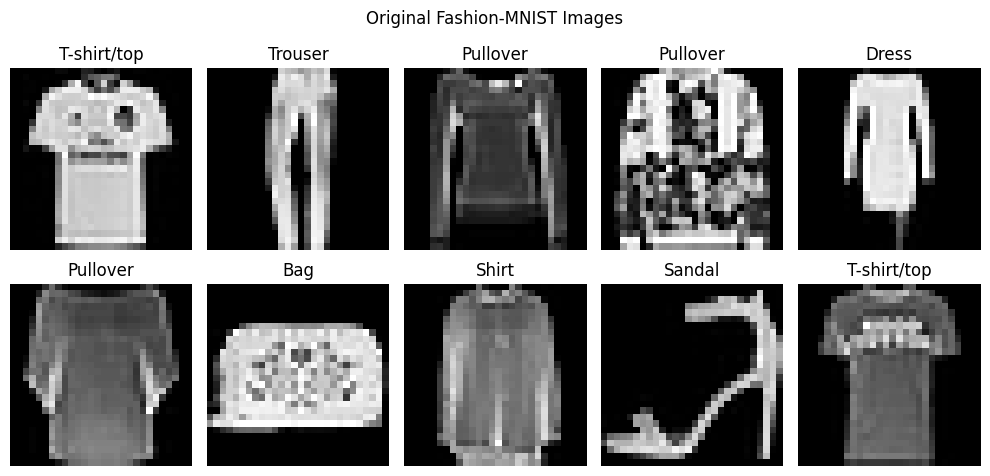


X shape after reshape: (10000, 28, 28, 1)

Training images: 8000
Testing images: 2000


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 232,650 (908.79 KB)

 Trainable params: 232,650 (908.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.6784 - loss: 0.8872 - val_accuracy: 0.7894 - val_loss: 0.5358
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.7992 - loss: 0.5295 - val_accuracy: 0.8188 - val_loss: 0.4978
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8356 - loss: 0.4321 - val_accuracy: 0.8344 - val_loss: 0.4562
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.8606 - loss: 0.3798 - val_accuracy: 0.8406 - val_loss: 0.4399
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8697 - loss: 0.3412 - val_accuracy: 0.8506 - val_loss: 0.3972
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8883 - loss: 0.2989 - val_accuracy: 0.8794 - val_loss: 0.3463
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9006 - loss: 0.2745 - val_accuracy: 0.8819 - val_loss: 0.3566
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9031 - loss: 0.2500 - val_accu

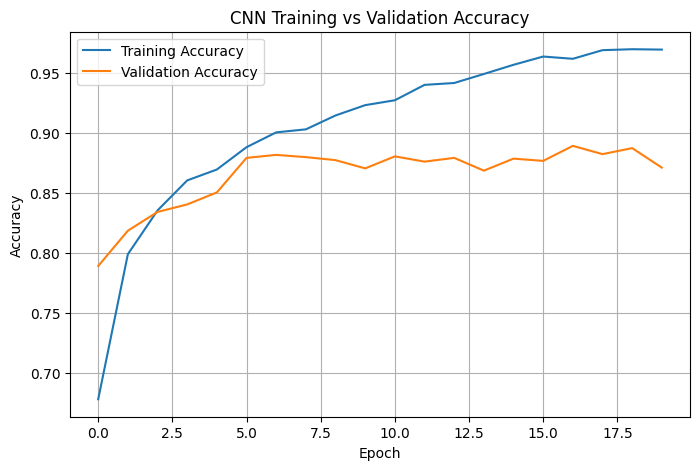

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


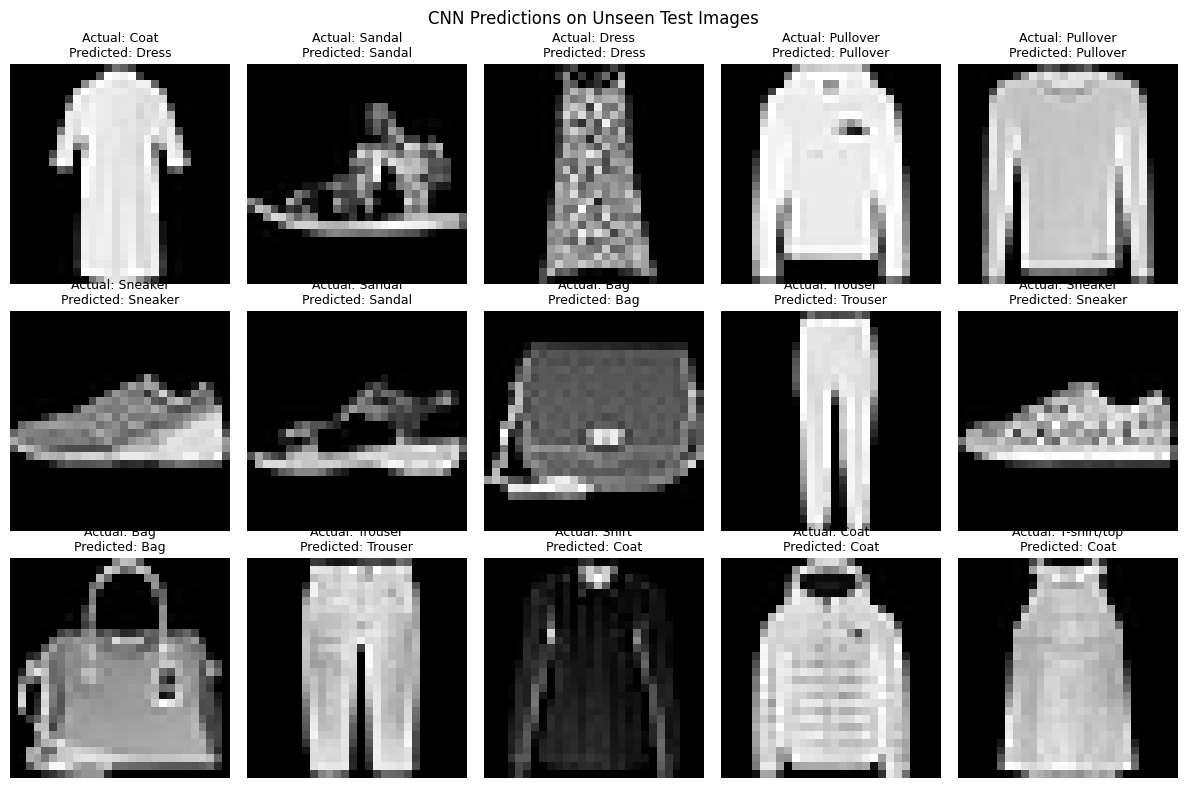

In [3]:
# ============================================================
# CNN + DENSE NEURAL NETWORK
# Fashion-MNIST CSV Dataset
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam


# ============================================================
# 1. LOAD DATASET
# ============================================================

df = pd.read_csv("fashion-mnist_test.csv")

print("Dataset Shape:", df.shape)
print(df.head())


# ============================================================
# 2. SEPARATE FEATURES AND LABEL
# ============================================================

# First column = label
y = df.iloc[:, 0].values

# Remaining 784 columns = image pixels
X = df.iloc[:, 1:].values

print("\nX shape before reshape:", X.shape)
print("y shape:", y.shape)


# ============================================================
# 3. SHOW SOME ORIGINAL IMAGES
# ============================================================

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

plt.figure(figsize=(10, 5))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    # Convert 784 pixels back into 28x28 image
    image = X[i].reshape(28, 28)

    plt.imshow(image, cmap="gray")
    plt.title(class_names[y[i]])
    plt.axis("off")

plt.suptitle("Original Fashion-MNIST Images")
plt.tight_layout()
plt.show()


# ============================================================
# 4. NORMALIZE PIXEL VALUES
# ============================================================

# Original pixels: 0 - 255
# Convert them to: 0 - 1

X = X / 255.0


# ============================================================
# 5. RESHAPE DATA FOR CNN
# ============================================================

# CNN expects:
# Number of images × Height × Width × Channels

X = X.reshape(-1, 28, 28, 1)

print("\nX shape after reshape:", X.shape)


# ============================================================
# 6. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining images:", X_train.shape[0])
print("Testing images:", X_test.shape[0])


# ============================================================
# 7. CREATE CNN + DENSE MODEL
# ============================================================

model = Sequential([

    # -------------------------
    # CNN FEATURE EXTRACTION
    # -------------------------

    Conv2D(
        32,
        kernel_size=(3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    ),

    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(
        64,
        kernel_size=(3, 3),
        activation="relu"
    ),

    MaxPooling2D(pool_size=(2, 2)),


    # -------------------------
    # CONVERT CNN FEATURES
    # INTO 1D VECTOR
    # -------------------------

    Flatten(),


    # -------------------------
    # DENSE LAYERS
    # -------------------------

    Dense(128, activation="relu"),

    Dense(64, activation="relu"),


    # -------------------------
    # OUTPUT LAYER
    # -------------------------

    Dense(10, activation="softmax")
])


# ============================================================
# 8. DISPLAY MODEL ARCHITECTURE
# ============================================================

model.summary()


# ============================================================
# 9. COMPILE MODEL
# ============================================================

model.compile(
    optimizer=Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# ============================================================
# 10. TRAIN MODEL
# ============================================================

history = model.fit(
    X_train,
    y_train,

    validation_split=0.2,

    epochs=20,

    batch_size=32,

    verbose=1
)


# ============================================================
# 11. TEST THE MODEL
# ============================================================

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\n===================================")
print("FINAL TEST RESULTS")
print("===================================")

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

print("Test Accuracy (%):", test_accuracy * 100)


# ============================================================
# 12. PLOT TRAINING & VALIDATION ACCURACY
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("CNN Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()


# ============================================================
# 13. MAKE PREDICTIONS
# ============================================================

predictions = model.predict(X_test)

# Get class with highest probability
predicted_classes = np.argmax(predictions, axis=1)


# ============================================================
# 14. SHOW TEST IMAGES + PREDICTIONS
# ============================================================

plt.figure(figsize=(12, 8))

for i in range(15):

    plt.subplot(3, 5, i + 1)

    plt.imshow(
        X_test[i].reshape(28, 28),
        cmap="gray"
    )

    actual = class_names[y_test[i]]
    predicted = class_names[predicted_classes[i]]

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}",
        fontsize=9
    )

    plt.axis("off")

plt.suptitle("CNN Predictions on Unseen Test Images")

plt.tight_layout()
plt.show()